In [ ]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells

In [2]:
import Lab5_PDK as pdk

In [3]:
import importlib
importlib.reload(pdk)

<module 'Lab5_PDK' from '/home/nixtropy/pic-upv-lab5-finalproject/Lab5_PDK.py'>

2026-05-20 09:28:40.685 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/2444904144.oas'


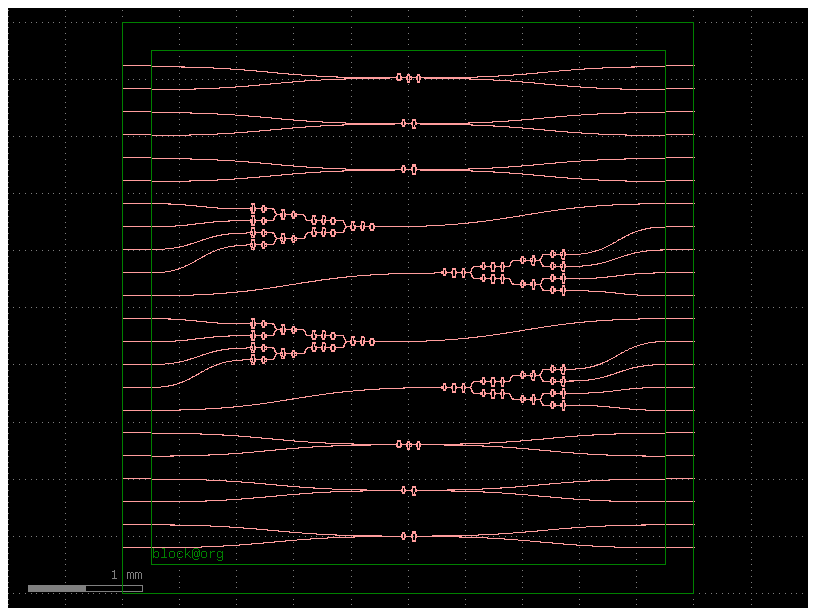

In [18]:
main = gf.Component()

#------------------------
# Parametros del DIE! ☠️
#------------------------
sp = 200
border = 250
dieW = 5000

#------------------------
# Parametros de los componentes
#------------------------

Lpi = 0.326  # um
L1 = 23.250  # um
L2_S1 = 9.217  # um
L2_S2 = 16.233  # um
Lpi_05 = 0.5 * Lpi # um
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

#------------------------
# Componentes del DIE! ☠️
#------------------------

dielab = pdk.die(layer_box="FLOORPLAN")

WDM = pdk.WDM()

S1 = pdk.ARTS1(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=22.63, lgthB=23.63, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S1, Lpi = Lpi
)

S2 = pdk.ARTS2(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S2, Lpi = 0
)

S2_mod = pdk.ARTS2(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S2, Lpi = Lpi_05
)

_dielab = main << dielab

#------------------------
# Bloque 1 de componentes
#------------------------

# Puertos de entrada y salida

start_b1 = 400 # Inicio del bloque 1

in_arr = main.add_ref(
    gf.components.straight_array(n=6, spacing=sp, length=border, cross_section=xs)
).dmovey(
    start_b1
)  

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=6, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(start_b1)
)

# Componentes

_S1 = main << S1
_S2 = main << S2
_S2_mod = main << S2_mod

# Posicionamiento componentes

_S1.dmovex(dieW/2 - _S1.dxsize/2).dmovey(in_arr['o8'].dy + sp/2)
_S2.dmovex(dieW/2 - _S2.dxsize/2).dmovey(in_arr['o10'].dy + sp/2)
_S2_mod.dmovex(dieW/2 - _S2_mod.dxsize/2).dmovey(in_arr['o12'].dy + sp/2)

# Conexiones de los componentes

gf.routing.route_single_sbend(main, port1=_S1['o2'], port2=in_arr['o7'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1['o1'], port2=in_arr['o8'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1['o3'], port2=out_arr['o6'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1['o4'], port2=out_arr['o5'], cross_section=xs)

gf.routing.route_single_sbend(main, port1=_S2['o2'], port2=in_arr['o9'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2['o1'], port2=in_arr['o10'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2['o3'], port2=out_arr['o4'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2['o4'], port2=out_arr['o3'], cross_section=xs)

gf.routing.route_single_sbend(main, port1=_S2_mod['o2'], port2=in_arr['o11'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_mod['o1'], port2=in_arr['o12'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_mod['o3'], port2=out_arr['o2'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_mod['o4'], port2=out_arr['o1'], cross_section=xs)

#------------------------
# Bloque 2 de componentes
#------------------------

# Especificaciones del ciclo for 

num_wdm_blocks = 2 # Cuantas filas de WDM queremos poner

routes_per_block = 5
n_routes = routes_per_block * num_wdm_blocks

# Puertos de entrada y salida

start_b2 = in_arr['o7'].dy + sp # Inicio del bloque 2

in_arr_WDM = main.add_ref(
    gf.components.straight_array(n=n_routes, spacing=sp, length=border, cross_section=xs)
).dmovey(
    start_b2
)

out_arr_WDM = (
    main.add_ref(
        gf.components.straight_array(n=n_routes, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(start_b2)
)

# Posicionamiento y conexion de los componentes  

wdm_refs = []

for block in range(num_wdm_blocks):
    lane0 = routes_per_block * block

    # Puertos del grupo actual, ordenados de abajo a arriba.
    out_ports = [out_arr_WDM[f"o{lane0 + i + 1}"] for i in range(routes_per_block)]
    in_ports = [in_arr_WDM[f"o{2 * n_routes - (lane0 + i)}"] for i in range(routes_per_block)]

    wdm_right = main << WDM
    wdm_left = main << WDM
    wdm_refs.append((wdm_left, wdm_right))

    # Colocar los dos WDM del bloque sin escribirlos uno a uno.
    wdm_right.dmovex(2 * dieW / 3 - WDM.dxsize / 2).dmovey(in_ports[1].dy)
    wdm_left.rotate(180).dmovex(dieW / 3 + WDM.dxsize / 2).dmovey(out_ports[3].dy)

    # Conexiones hacia el array de salida.
    for wdm_port, out_port in zip(("o6", "o5", "o4", "o3"), out_ports[:4]):
        gf.routing.route_single_sbend(main, port1=wdm_right[wdm_port], port2=out_port, cross_section=xs)
    gf.routing.route_single_sbend(main, port1=wdm_right["o1"], port2=in_ports[0], cross_section=xs)

    # Conexiones hacia el array de entrada.
    for wdm_port, in_port in zip(("o6", "o5", "o4", "o3"), reversed(in_ports[1:])):
        gf.routing.route_single_sbend(main, port1=wdm_left[wdm_port], port2=in_port, cross_section=xs)
    gf.routing.route_single_sbend(main, port1=wdm_left["o2"], port2=out_ports[4], cross_section=xs)

#------------------------
# Bloque 3 de componentes
#------------------------

# Puertos de entrada y salida

start_b3 = in_arr_WDM['o11'].dy + sp # Inicio del bloque 1

in_arr_b3 = main.add_ref(
    gf.components.straight_array(n=6, spacing=sp, length=border, cross_section=xs)
).dmovey(
    start_b3
)  

out_arr_b3 = (
    main.add_ref(
        gf.components.straight_array(n=6, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(start_b3)
)

# Componentes

_S1_b3 = main << S1
_S2_b3 = main << S2
_S2_b3_mod = main << S2_mod

# Posicionamiento componentes

_S1_b3.dmovex(dieW/2 - _S1_b3.dxsize/2).dmovey(in_arr_b3['o8'].dy + sp/2)
_S2_b3.dmovex(dieW/2 - _S2_b3.dxsize/2).dmovey(in_arr_b3['o10'].dy + sp/2)
_S2_b3_mod.dmovex(dieW/2 - _S2_b3_mod.dxsize/2).dmovey(in_arr_b3['o12'].dy + sp/2)

# Conexiones de los componentes

gf.routing.route_single_sbend(main, port1=_S1_b3['o2'], port2=in_arr_b3['o7'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1_b3['o1'], port2=in_arr_b3['o8'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1_b3['o3'], port2=out_arr_b3['o6'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1_b3['o4'], port2=out_arr_b3['o5'], cross_section=xs)

gf.routing.route_single_sbend(main, port1=_S2_b3['o2'], port2=in_arr_b3['o9'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_b3['o1'], port2=in_arr_b3['o10'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_b3['o3'], port2=out_arr_b3['o4'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_b3['o4'], port2=out_arr_b3['o3'], cross_section=xs)

gf.routing.route_single_sbend(main, port1=_S2_b3_mod['o2'], port2=in_arr_b3['o11'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_b3_mod['o1'], port2=in_arr_b3['o12'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_b3_mod['o3'], port2=out_arr_b3['o2'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_b3_mod['o4'], port2=out_arr_b3['o1'], cross_section=xs)


# main.add_ports(in_arr_WDM.ports)
# main.add_ports(out_arr_WDM.ports)
# main.add_ports(in_arr.ports)
# main.add_ports(out_arr.ports)
# main.draw_ports()
main.plot()
main.show()

In [ ]:
main.write_gds("Lab5_Die.gds",with_metadata=False)